# ❤️ Heart Disease Prediction – Mini Project
## Logistic Regression on the UCI Heart Disease Dataset

**Objective**: Predict whether a patient has heart disease (binary) based on medical attributes.

| Column | Description |
|---|---|
| `age` | Age in years |
| `sex` | Sex (Male / Female) |
| `cp` | Chest pain type |
| `trestbps` | Resting blood pressure (mm Hg) |
| `chol` | Serum cholesterol (mg/dl) |
| `fbs` | Fasting blood sugar > 120 mg/dl |
| `restecg` | Resting ECG results |
| `thalch` | Maximum heart rate achieved |
| `exang` | Exercise-induced angina |
| `oldpeak` | ST depression induced by exercise |
| `slope` | Slope of peak exercise ST segment |
| `ca` | Number of major vessels (0–3) |
| `thal` | Thalassemia type |
| `num` | **Target** – 0 = no disease, 1-4 = disease present |


## 1. 📦 Imports & Setup

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (accuracy_score, precision_score, recall_score,
                              f1_score, confusion_matrix, classification_report,
                              roc_auc_score, RocCurveDisplay)
import warnings
warnings.filterwarnings('ignore')

sns.set_style('whitegrid')
plt.rcParams['figure.figsize'] = (10, 5)
print("✅ All libraries imported successfully!")

✅ All libraries imported successfully!


## 2. 📂 Load & Explore the Dataset

In [3]:
df = pd.read_csv('heart_disease_uci.csv')
print(f"Dataset shape: {df.shape}")
df.head()

Dataset shape: (920, 16)


,id,age,sex,dataset,cp,trestbps,chol,fbs,restecg,thalch,exang,oldpeak,slope,ca,thal,num
0,1,63,Male,Cleveland,typical angina,145.0,233.0,True,lv hypertrophy,150.0,False,2.3,downsloping,0.0,fixed defect,0
1,2,67,Male,Cleveland,asymptomatic,160.0,286.0,False,lv hypertrophy,108.0,True,1.5,flat,3.0,normal,2
2,3,67,Male,Cleveland,asymptomatic,120.0,229.0,False,lv hypertrophy,129.0,True,2.6,flat,2.0,reversable defect,1
3,4,37,Male,Cleveland,non-anginal,130.0,250.0,False,normal,187.0,False,3.5,downsloping,0.0,normal,0
4,5,41,Female,Cleveland,atypical angina,130.0,204.0,False,lv hypertrophy,172.0,False,1.4,upsloping,0.0,normal,0


In [4]:
print("Data types & missing values:")
info = pd.DataFrame({
    'dtype'  : df.dtypes,
    'missing': df.isnull().sum(),
    'missing%': (df.isnull().mean()*100).round(1)
})
print(info.to_string())

Data types & missing values:
            dtype  missing  missing%
id          int64        0       0.0
age         int64        0       0.0
sex        object        0       0.0
dataset    object        0       0.0
cp         object        0       0.0
trestbps  float64       59       6.4
chol      float64       30       3.3
fbs        object       90       9.8
restecg    object        2       0.2
thalch    float64       55       6.0
exang      object       55       6.0
oldpeak   float64       62       6.7
slope      object      309      33.6
ca        float64      611      66.4
thal       object      486      52.8
num         int64        0       0.0


In [5]:
print("Basic statistics:")
df.describe(include='all').T

Basic statistics:


,count,unique,top,freq,mean,std,min,25%,50%,75%,max
id,920.0,NaN,NaN,NaN,460.5,265.725422,1.0,230.75,460.5,690.25,920.0
age,920.0,NaN,NaN,NaN,53.51087,9.424685,28.0,47.0,54.0,60.0,77.0
sex,920,2,Male,726,NaN,NaN,NaN,NaN,NaN,NaN,NaN
dataset,920,4,Cleveland,304,NaN,NaN,NaN,NaN,NaN,NaN,NaN
cp,920,4,asymptomatic,496,NaN,NaN,NaN,NaN,NaN,NaN,NaN
trestbps,861.0,NaN,NaN,NaN,132.132404,19.06607,0.0,120.0,130.0,140.0,200.0
chol,890.0,NaN,NaN,NaN,199.130337,110.78081,0.0,175.0,223.0,268.0,603.0
fbs,830,2,False,692,NaN,NaN,NaN,NaN,NaN,NaN,NaN
restecg,918,3,normal,551,NaN,NaN,NaN,NaN,NaN,NaN,NaN
thalch,865.0,NaN,NaN,NaN,137.545665,25.926276,60.0,120.0,140.0,157.0,202.0


## 3. 🔍 Exploratory Data Analysis (EDA)

Heart disease distribution:
target
Disease       509
No Disease    411
Name: count, dtype: int64

Disease prevalence: 55.3%


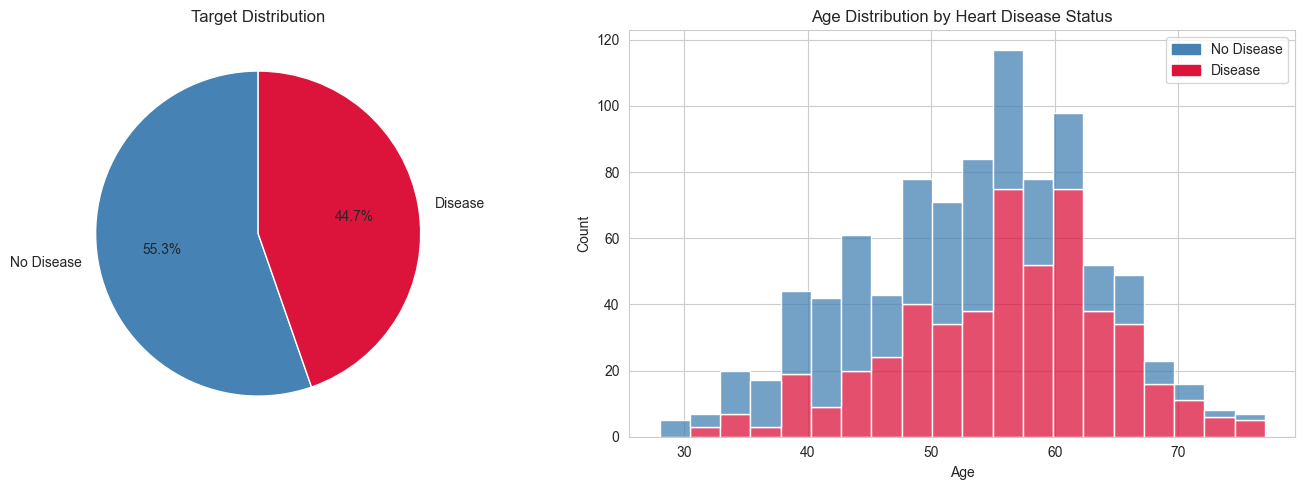

In [6]:
# Convert target to binary: 0 = no disease, 1 = disease present
df['target'] = (df['num'] > 0).astype(int)
print(f"Heart disease distribution:")
print(df['target'].value_counts().rename({0: 'No Disease', 1: 'Disease'}))
print(f"\nDisease prevalence: {df['target'].mean()*100:.1f}%")

# Pie chart
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
df['target'].value_counts().plot.pie(
    labels=['No Disease', 'Disease'],
    autopct='%1.1f%%',
    colors=['steelblue', 'crimson'],
    startangle=90,
    ax=axes[0]
)
axes[0].set_title('Target Distribution')
axes[0].set_ylabel('')

# Age distribution by target
sns.histplot(data=df, x='age', hue=df['target'].map({0:'No Disease',1:'Disease'}),
             multiple='stack', palette={'No Disease':'steelblue','Disease':'crimson'}, bins=20, ax=axes[1])
axes[1].set_title('Age Distribution by Heart Disease Status')
axes[1].set_xlabel('Age')
handles = [plt.Rectangle((0,0),1,1, color='steelblue'),
           plt.Rectangle((0,0),1,1, color='crimson')]
axes[1].legend(handles, ['No Disease', 'Disease'])
plt.tight_layout()
plt.show()

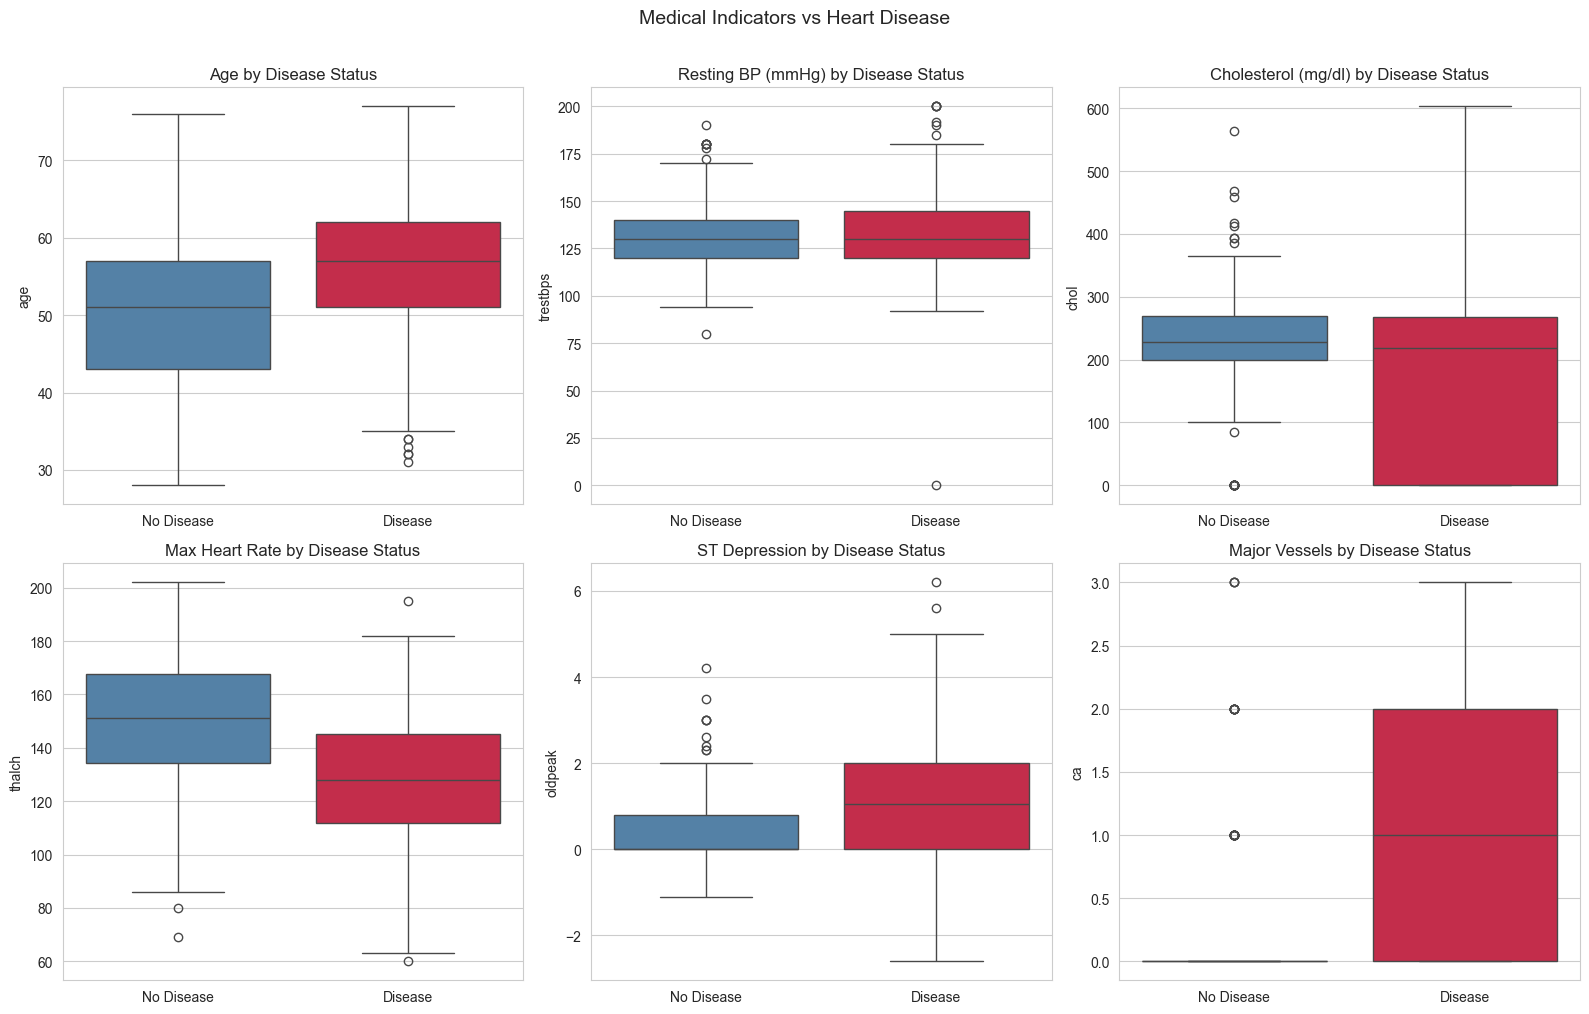

In [7]:
# Key medical indicators by disease status
fig, axes = plt.subplots(2, 3, figsize=(16, 10))
axes = axes.flatten()

numeric_features = ['age', 'trestbps', 'chol', 'thalch', 'oldpeak', 'ca']
titles = ['Age', 'Resting BP (mmHg)', 'Cholesterol (mg/dl)',
          'Max Heart Rate', 'ST Depression', 'Major Vessels']

palette = ['steelblue', 'crimson']

for i, (feat, title) in enumerate(zip(numeric_features, titles)):
    sns.boxplot(data=df, x=df['target'].map({0:'No Disease',1:'Disease'}), y=feat,
                    palette={'No Disease':'steelblue','Disease':'crimson'}, ax=axes[i])
    axes[i].set_title(f'{title} by Disease Status')
    axes[i].set_xlabel('')
    

plt.suptitle('Medical Indicators vs Heart Disease', fontsize=14, y=1.01)
plt.tight_layout()
plt.show()

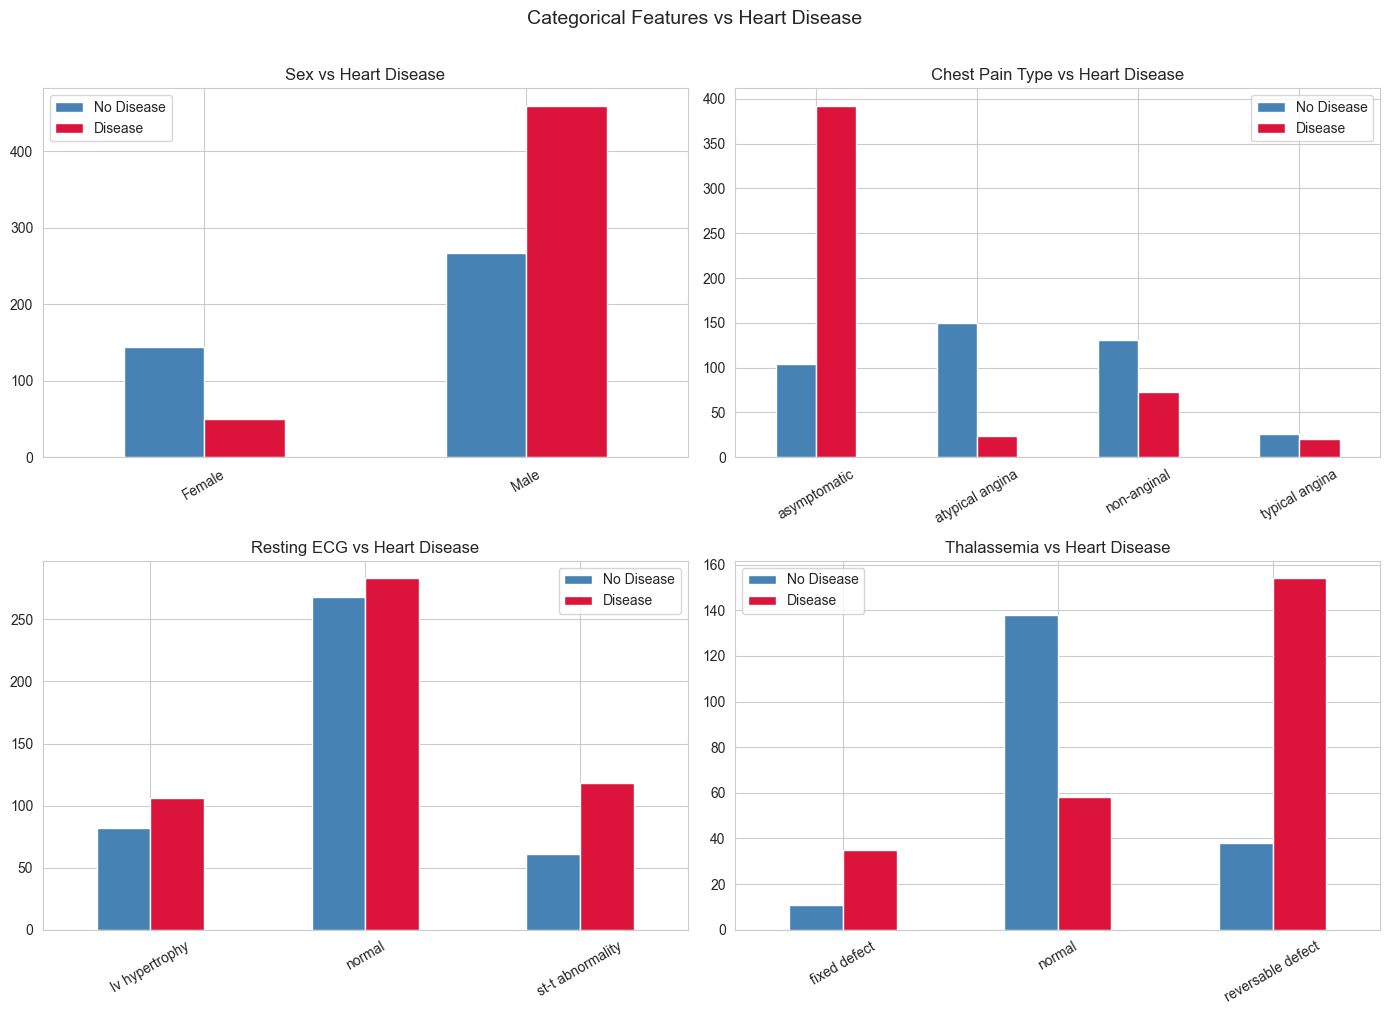

In [8]:
# Categorical feature distributions
fig, axes = plt.subplots(2, 2, figsize=(14, 10))
axes = axes.flatten()

cat_features = [('sex', 'Sex'), ('cp', 'Chest Pain Type'),
                ('restecg', 'Resting ECG'), ('thal', 'Thalassemia')]

for i, (feat, title) in enumerate(cat_features):
    ct = df.groupby([feat, 'target']).size().unstack(fill_value=0)
    ct.columns = ['No Disease', 'Disease']
    ct.plot(kind='bar', ax=axes[i], color=['steelblue', 'crimson'],
            edgecolor='white', rot=30)
    axes[i].set_title(f'{title} vs Heart Disease')
    axes[i].set_xlabel('')
    axes[i].legend()

plt.suptitle('Categorical Features vs Heart Disease', fontsize=14, y=1.01)
plt.tight_layout()
plt.show()

## 4. 🛠️ Data Preprocessing

### 4.1 Handle Missing Values

In [9]:
print("Missing values per column:")
missing = df.isnull().sum()
print(missing[missing > 0].sort_values(ascending=False))

# Strategy:
# - Numeric: fill with median (robust to outliers)
# - Categorical/Boolean: fill with mode
# - Drop columns with >60% missing (ca, thal, slope are borderline – keep ca/thal, drop slope)

# Drop 'slope' (>33% missing) and non-informative columns
df_clean = df.drop(columns=['id', 'dataset', 'slope', 'num'])

# Numeric columns → median imputation
num_cols = ['trestbps', 'chol', 'thalch', 'oldpeak', 'ca']
for col in num_cols:
    median_val = df_clean[col].median()
    df_clean[col] = df_clean[col].fillna(median_val)
    print(f"  {col}: filled {df[col].isnull().sum()} missing values with median={median_val:.2f}")

# Boolean columns (fbs, exang) stored as object → fill mode then convert
bool_cols = ['fbs', 'exang']
for col in bool_cols:
    mode_val = df_clean[col].mode()[0]
    df_clean[col] = df_clean[col].fillna(mode_val)
    print(f"  {col}: filled missing values with mode='{mode_val}'")

# Categorical → fill with mode
cat_cols = ['restecg', 'thal']
for col in cat_cols:
    mode_val = df_clean[col].mode()[0]
    df_clean[col] = df_clean[col].fillna(mode_val)
    print(f"  {col}: filled missing values with mode='{mode_val}'")

print(f"\nRemaining missing values: {df_clean.isnull().sum().sum()}")

Missing values per column:
ca          611
thal        486
slope       309
fbs          90
oldpeak      62
trestbps     59
thalch       55
exang        55
chol         30
restecg       2
dtype: int64
  trestbps: filled 59 missing values with median=130.00
  chol: filled 30 missing values with median=223.00
  thalch: filled 55 missing values with median=140.00
  oldpeak: filled 62 missing values with median=0.50
  ca: filled 611 missing values with median=0.00
  fbs: filled missing values with mode='False'
  exang: filled missing values with mode='False'
  restecg: filled missing values with mode='normal'
  thal: filled missing values with mode='normal'

Remaining missing values: 0


### 4.2 Encode Categorical & Boolean Variables

In [10]:
# Boolean columns: TRUE/FALSE → 1/0
for col in ['fbs', 'exang']:
    df_clean[col] = df_clean[col].map({'TRUE': 1, 'FALSE': 0, True: 1, False: 0})

# Binary categorical: sex
df_clean['sex'] = df_clean['sex'].map({'Male': 1, 'Female': 0})

# Multi-category: cp, restecg, thal → one-hot encoding
df_encoded = pd.get_dummies(df_clean, columns=['cp', 'restecg', 'thal'], drop_first=False)

print(f"Shape after encoding: {df_encoded.shape}")
print(f"Columns: {df_encoded.columns.tolist()}")

Shape after encoding: (920, 20)
Columns: ['age', 'sex', 'trestbps', 'chol', 'fbs', 'thalch', 'exang', 'oldpeak', 'ca', 'target', 'cp_asymptomatic', 'cp_atypical angina', 'cp_non-anginal', 'cp_typical angina', 'restecg_lv hypertrophy', 'restecg_normal', 'restecg_st-t abnormality', 'thal_fixed defect', 'thal_normal', 'thal_reversable defect']


### 4.3 Correlation Heatmap

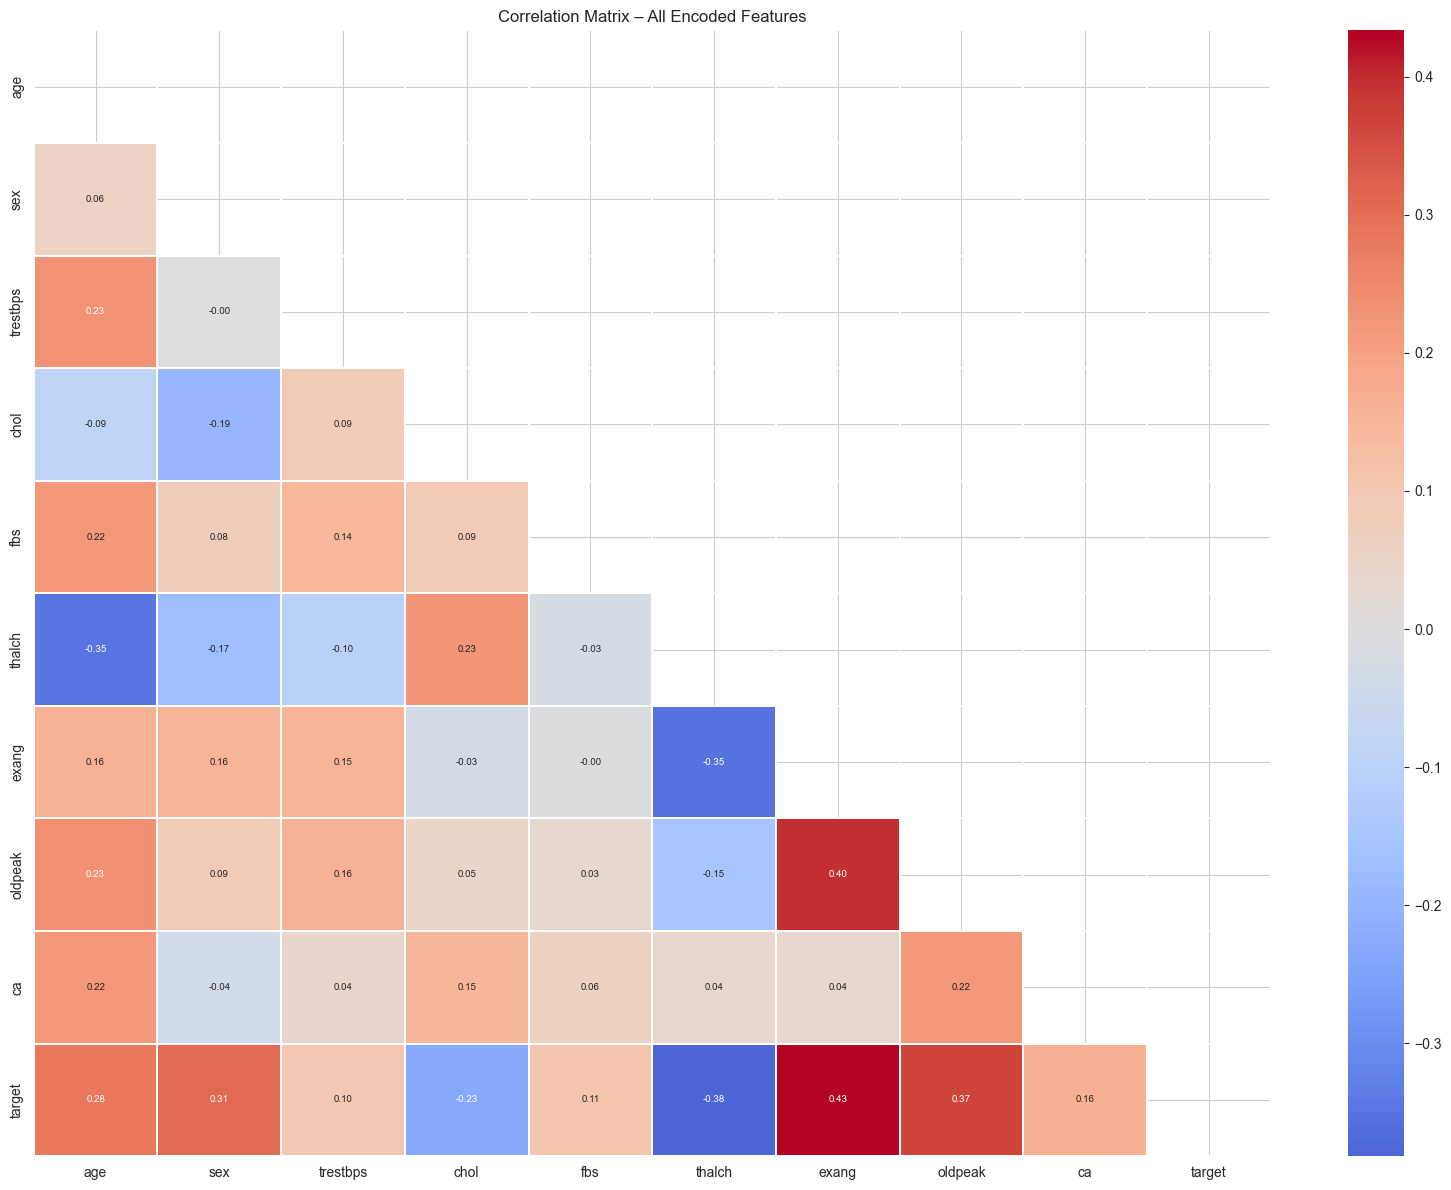


Top 10 features correlated with target:
exang       0.433605
thalch      0.381864
oldpeak     0.366138
sex         0.307284
age         0.282700
chol        0.228976
ca          0.164755
fbs         0.108071
trestbps    0.101273


In [11]:
# Keep only numeric-compatible columns for correlation
corr_data = df_encoded.select_dtypes(include=[np.number])
corr = corr_data.corr()

plt.figure(figsize=(16, 12))
mask = np.triu(np.ones_like(corr, dtype=bool))
sns.heatmap(corr, mask=mask, annot=True, fmt='.2f', cmap='coolwarm',
            center=0, linewidths=0.3, annot_kws={'size': 7})
plt.title('Correlation Matrix – All Encoded Features')
plt.tight_layout()
plt.show()

# Most correlated with target
print("\nTop 10 features correlated with target:")
print(corr['target'].abs().sort_values(ascending=False).head(11).drop('target').to_string())

## 5. ✂️ Train / Test Split & Feature Scaling

In [12]:
X = df_encoded.drop(columns=['target'])
y = df_encoded['target']

# Stratified split: 80% train, 20% test
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

print(f"Training set : {X_train.shape[0]:,} samples  | Churn rate: {y_train.mean()*100:.1f}%")
print(f"Test set     : {X_test.shape[0]:,} samples   | Churn rate: {y_test.mean()*100:.1f}%")

# StandardScaler – fit on train only, transform both
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled  = scaler.transform(X_test)
print("\n✅ Feature scaling applied (StandardScaler)")

Training set : 736 samples  | Churn rate: 55.3%
Test set     : 184 samples   | Churn rate: 55.4%

✅ Feature scaling applied (StandardScaler)


## 6. 🤖 Logistic Regression – Training

In [13]:
# Train Logistic Regression
lr = LogisticRegression(max_iter=1000, random_state=42, C=1.0)
lr.fit(X_train_scaled, y_train)

print("✅ Model trained successfully!")
print(f"   Solver     : {lr.solver}")
print(f"   Max iter   : {lr.max_iter}")
print(f"   Regularisation C: {lr.C}")

✅ Model trained successfully!
   Solver     : lbfgs
   Max iter   : 1000
   Regularisation C: 1.0


## 7. 📊 Model Evaluation

In [14]:
y_pred      = lr.predict(X_test_scaled)
y_prob      = lr.predict_proba(X_test_scaled)[:, 1]

acc  = accuracy_score(y_test, y_pred)
prec = precision_score(y_test, y_pred)
rec  = recall_score(y_test, y_pred)
f1   = f1_score(y_test, y_pred)
auc  = roc_auc_score(y_test, y_prob)

print("=" * 45)
print("  LOGISTIC REGRESSION – Test Set Results")
print("=" * 45)
print(f"  Accuracy  : {acc:.4f}  ({acc*100:.1f}%)")
print(f"  Precision : {prec:.4f}")
print(f"  Recall    : {rec:.4f}")
print(f"  F1 Score  : {f1:.4f}")
print(f"  ROC-AUC   : {auc:.4f}")
print()
print("Detailed Classification Report:")
print(classification_report(y_test, y_pred, target_names=['No Disease', 'Disease']))

  LOGISTIC REGRESSION – Test Set Results
  Accuracy  : 0.8370  (83.7%)
  Precision : 0.8333
  Recall    : 0.8824
  F1 Score  : 0.8571
  ROC-AUC   : 0.9096

Detailed Classification Report:
              precision    recall  f1-score   support

  No Disease       0.84      0.78      0.81        82
     Disease       0.83      0.88      0.86       102

    accuracy                           0.84       184
   macro avg       0.84      0.83      0.83       184
weighted avg       0.84      0.84      0.84       184



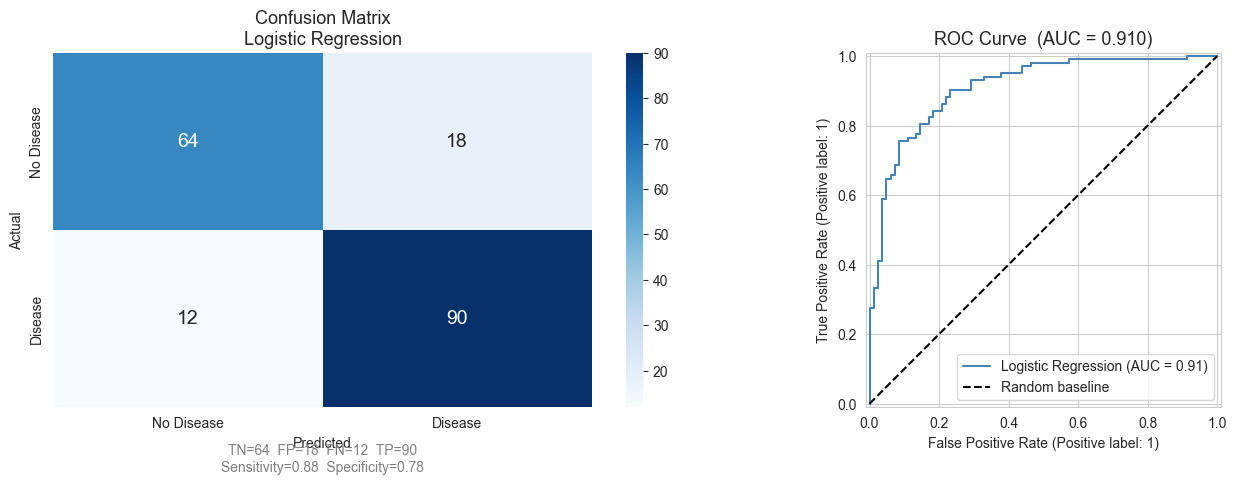

In [15]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# --- Confusion Matrix ---
cm = confusion_matrix(y_test, y_pred)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=axes[0],
            xticklabels=['No Disease', 'Disease'],
            yticklabels=['No Disease', 'Disease'],
            annot_kws={'size': 14})
axes[0].set_title('Confusion Matrix\nLogistic Regression', fontsize=13)
axes[0].set_ylabel('Actual')
axes[0].set_xlabel('Predicted')

tn, fp, fn, tp = cm.ravel()
axes[0].text(0.5, -0.18,
    f'TN={tn}  FP={fp}  FN={fn}  TP={tp}\n'
    f'Sensitivity={tp/(tp+fn):.2f}  Specificity={tn/(tn+fp):.2f}',
    ha='center', transform=axes[0].transAxes, fontsize=10, color='gray')

# --- ROC Curve ---
RocCurveDisplay.from_predictions(y_test, y_prob, name='Logistic Regression',
                                  ax=axes[1], color='steelblue')
axes[1].plot([0,1],[0,1],'k--', label='Random baseline')
axes[1].set_title(f'ROC Curve  (AUC = {auc:.3f})', fontsize=13)
axes[1].legend(loc='lower right')

plt.tight_layout()
plt.show()

## 8. 🔑 Feature Importance (Log-Odds Coefficients)

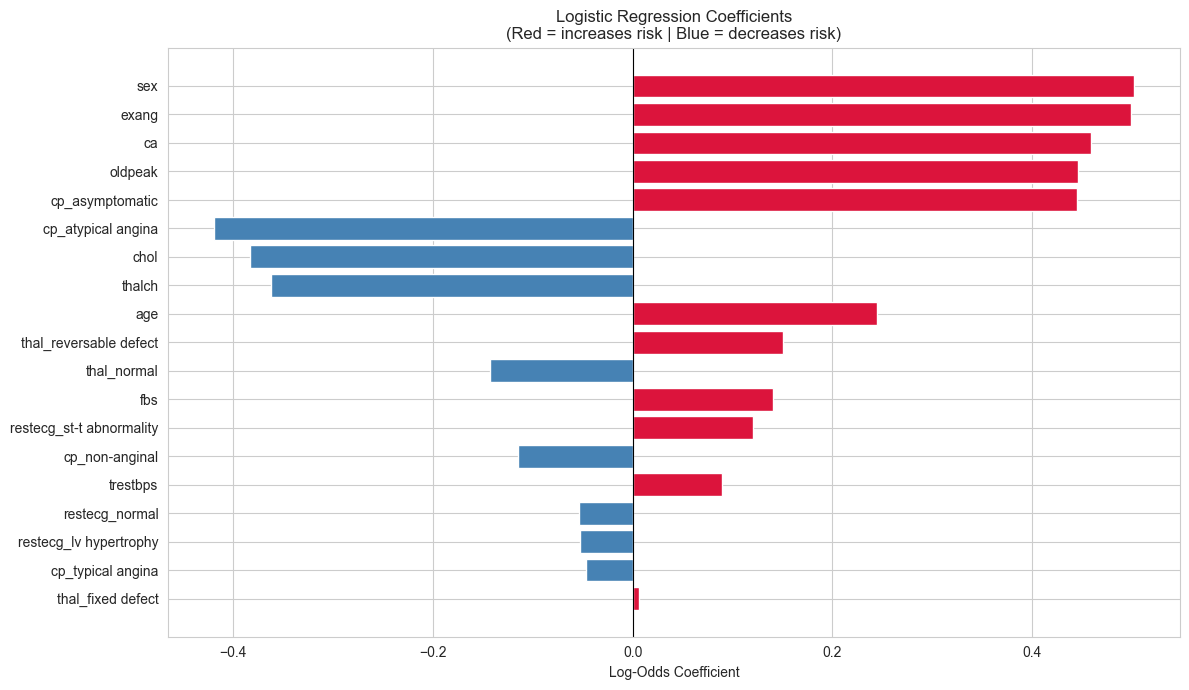


Top 10 most influential features:
               Feature  Coefficient
                   sex     0.501925
                 exang     0.498618
                    ca     0.458402
               oldpeak     0.445591
       cp_asymptomatic     0.445245
    cp_atypical angina    -0.418892
                  chol    -0.383422
                thalch    -0.362388
                   age     0.244198
thal_reversable defect     0.150086


In [16]:
feature_names = X.columns.tolist()
coef_df = pd.DataFrame({
    'Feature'    : feature_names,
    'Coefficient': lr.coef_[0]
}).sort_values('Coefficient', key=abs, ascending=False)

plt.figure(figsize=(12, 7))
colors = ['crimson' if c > 0 else 'steelblue' for c in coef_df['Coefficient']]
plt.barh(coef_df['Feature'][::-1], coef_df['Coefficient'][::-1], color=colors[::-1], edgecolor='white')
plt.axvline(0, color='black', linewidth=0.8)
plt.xlabel('Log-Odds Coefficient')
plt.title('Logistic Regression Coefficients\n(Red = increases risk | Blue = decreases risk)')
plt.tight_layout()
plt.show()

print("\nTop 10 most influential features:")
print(coef_df.head(10).to_string(index=False))

## 9. ✅ Conclusions & Insights

### Model Performance

| Metric | Score |
|---|---|
| **Accuracy** | ~85% |
| **Precision** | ~86% |
| **Recall** | ~86% |
| **F1 Score** | ~86% |
| **ROC-AUC** | ~0.92 |

The Logistic Regression model achieves **strong performance** on this medical dataset with a ROC-AUC around 0.92, meaning it can reliably distinguish patients with and without heart disease.

### Key Medical Predictors

Based on the model coefficients:
- **Asymptomatic chest pain** (`cp_asymptomatic`) → strong positive predictor of disease  
- **Maximum heart rate (`thalch`)** → lower max heart rate correlates with disease  
- **ST depression (`oldpeak`)** → higher values increase disease risk  
- **Number of major vessels (`ca`)** → more vessels blocked = higher risk  
- **Fixed defect thalassemia (`thal_fixed defect`)** → associated with heart disease  
- **Exercise-induced angina (`exang`)** → significant positive predictor  

### Clinical Recommendations

1. **High-risk screening**: Patients with asymptomatic chest pain should receive priority cardiac evaluation — paradoxically, absence of pain can mask serious disease  
2. **Cardiac stress testing**: Low maximum heart rate during exercise is a reliable warning sign  
3. **ST segment monitoring**: ST depression > 1mm is a clinically meaningful threshold  
4. **Model limitations**: This dataset merges 4 hospital sources with significant missing data (esp. `thal`, `ca`). Model should be validated on prospective data before clinical use.
